In [4]:
import pandas as pd
import os
from scipy.io import arff

In [5]:
datasets_path = "../../data/classification/train_test/"
datasets = sorted(os.listdir(datasets_path))

In [7]:
rows = []

for dataset in datasets:
    df = pd.DataFrame(arff.loadarff(f"{datasets_path}{dataset}")[0])
    rows.append({
        "dataset": dataset,
        "rows": df.shape[0],
        "columns": df.shape[1],
    })

summary_df = pd.DataFrame(rows)


In [8]:
summary_df

,dataset,rows,columns
0,anneal.arff,898,39
1,audiology.arff,226,70
2,auto-mpg.arff,398,8
3,autos.arff,205,26
4,balance-scale.arff,625,5
5,breast-cancer.arff,286,10
6,breast-w.arff,699,10
7,bupa-liver-disorders.arff,345,7
8,car.arff,1728,7
9,cleveland.arff,303,14


In [ ]:
summary_df.to_csv("classification_datasets_summary.csv", index=False)


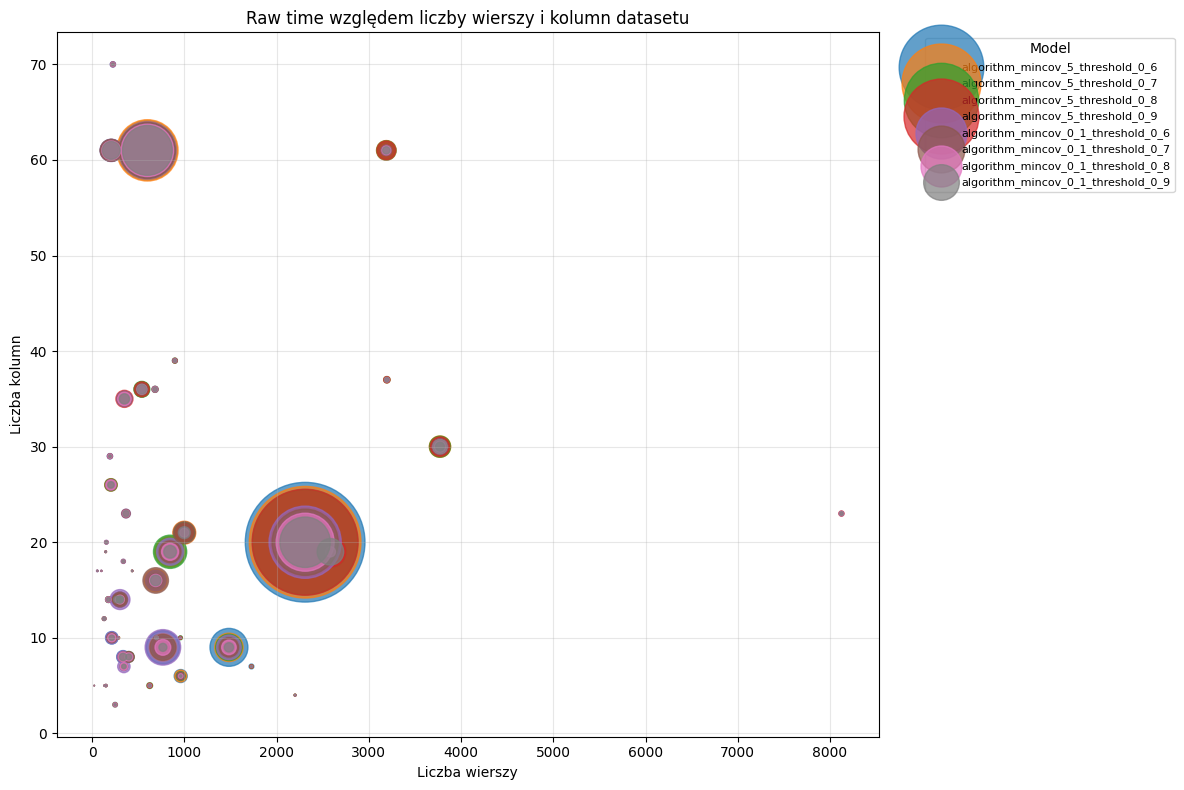

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Wczytanie plików ===
datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)

# === 2. Połączenie danych po nazwie datasetu ===
df = results.merge(
    datasets,
    on="dataset",
    how="left"
)

# === 3. Sprawdzenie, czy wszystko się poprawnie połączyło ===
missing = df[df["rows"].isna() | df["columns"].isna()]

if not missing.empty:
    print("Uwaga: dla części wyników nie znaleziono rows/columns:")
    print(missing["dataset"].unique())

# === 4. Konwersja typów liczbowych ===
df["rows"] = pd.to_numeric(df["rows"], errors="coerce")
df["columns"] = pd.to_numeric(df["columns"], errors="coerce")
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")

df = df.dropna(subset=["rows", "columns", "raw_time", "model"])

# === 5. Wykres ===
plt.figure(figsize=(12, 8))

models = df["model"].unique()

for model in models:
    subset = df[df["model"] == model]

    scatter = plt.scatter(
        subset["rows"],
        subset["columns"],
        s=subset["raw_time"] * 3,   # wielkość punktu zależna od raw_time
        alpha=0.7,
        label=model
    )

plt.xlabel("Liczba wierszy")
plt.ylabel("Liczba kolumn")
plt.title("Raw time względem liczby wierszy i kolumn datasetu")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

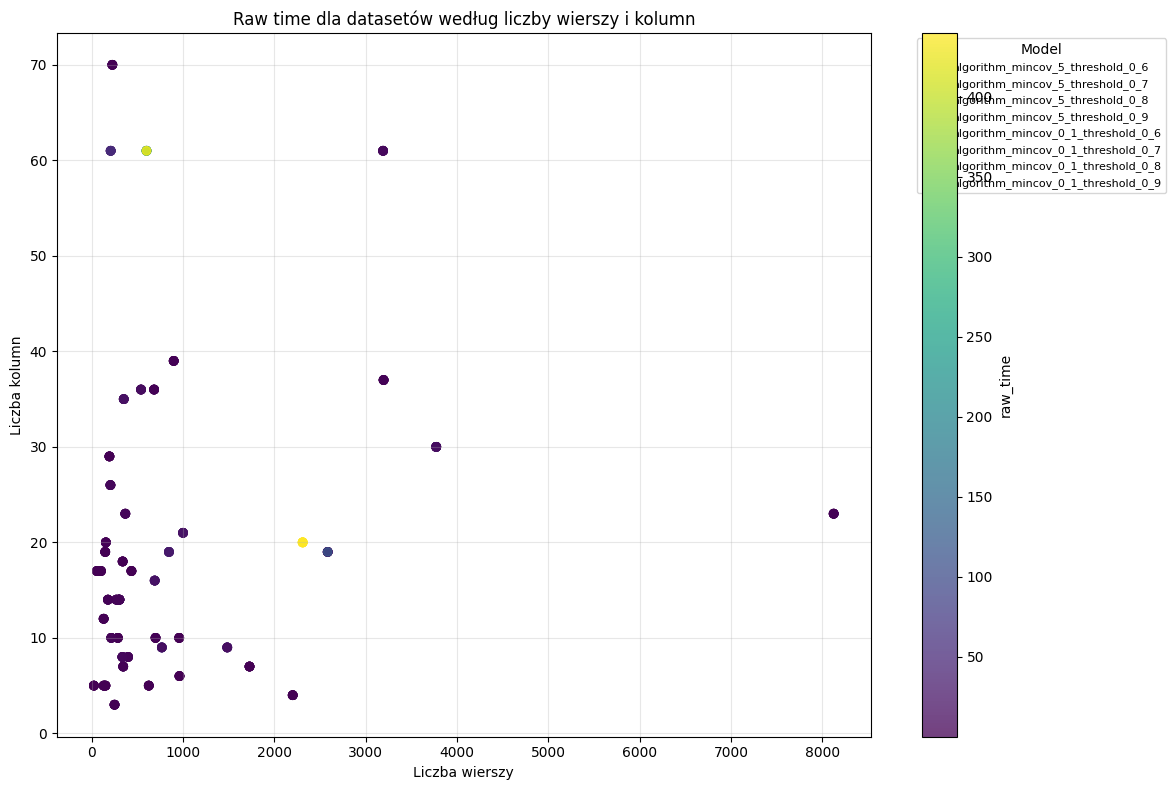

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)

df = results.merge(datasets, on="dataset", how="left")

df["rows"] = pd.to_numeric(df["rows"], errors="coerce")
df["columns"] = pd.to_numeric(df["columns"], errors="coerce")
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")

df = df.dropna(subset=["rows", "columns", "raw_time", "model"])

plt.figure(figsize=(12, 8))

for model in df["model"].unique():
    subset = df[df["model"] == model]

    plt.scatter(
        subset["rows"],
        subset["columns"],
        c=subset["raw_time"],
        cmap="viridis",
        alpha=0.75,
        label=model
    )

plt.xlabel("Liczba wierszy")
plt.ylabel("Liczba kolumn")
plt.title("Raw time dla datasetów według liczby wierszy i kolumn")

cbar = plt.colorbar()
cbar.set_label("raw_time")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

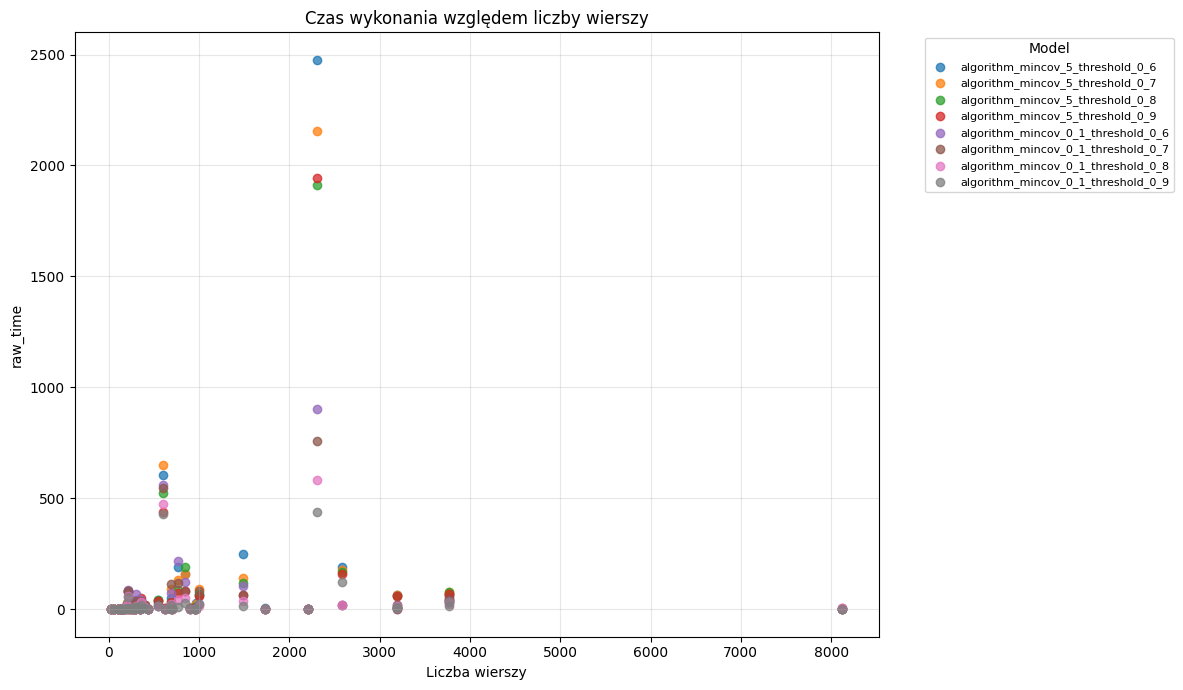

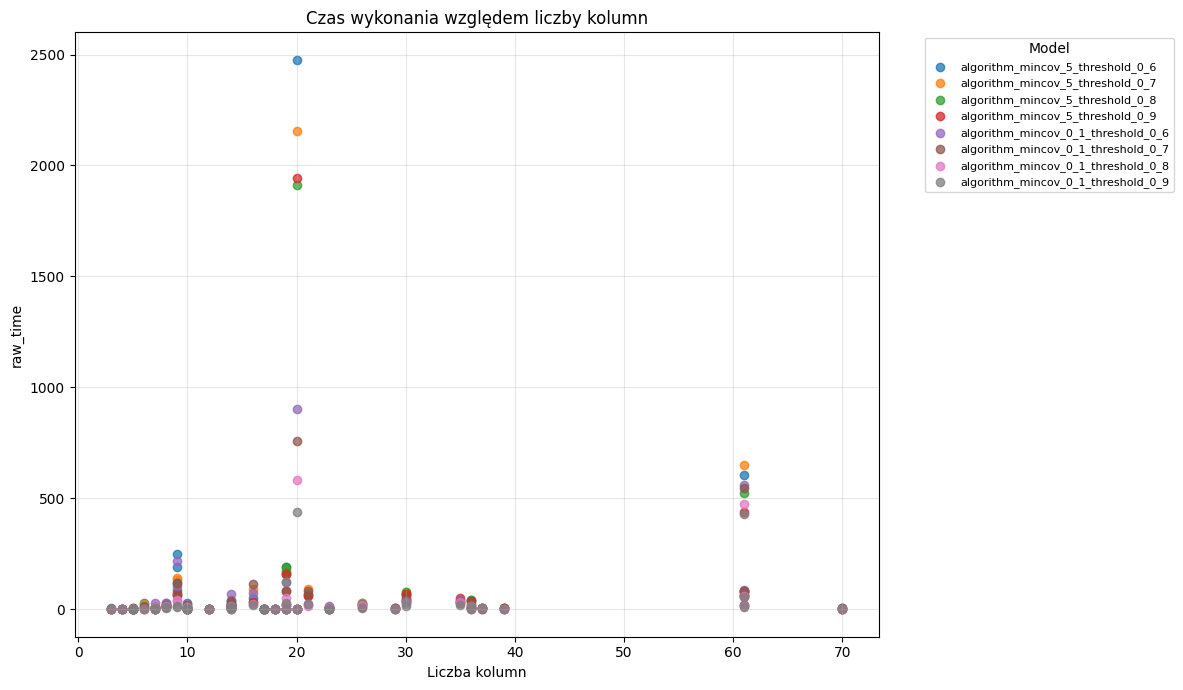

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Wczytanie plików ===
datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)
# === 2. Połączenie danych ===
df = results.merge(datasets, on="dataset", how="left")

# === 3. Konwersja typów ===
df["rows"] = pd.to_numeric(df["rows"], errors="coerce")
df["columns"] = pd.to_numeric(df["columns"], errors="coerce")
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")

df = df.dropna(subset=["rows", "columns", "raw_time", "model"])

# === 4. Wykres 1: raw_time względem liczby wierszy ===
plt.figure(figsize=(12, 7))

for model in df["model"].unique():
    subset = df[df["model"] == model]

    plt.scatter(
        subset["rows"],
        subset["raw_time"],
        alpha=0.75,
        label=model
    )

plt.xlabel("Liczba wierszy")
plt.ylabel("raw_time")
plt.title("Czas wykonania względem liczby wierszy")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# === 5. Wykres 2: raw_time względem liczby kolumn ===
plt.figure(figsize=(12, 7))

for model in df["model"].unique():
    subset = df[df["model"] == model]

    plt.scatter(
        subset["columns"],
        subset["raw_time"],
        alpha=0.75,
        label=model
    )

plt.xlabel("Liczba kolumn")
plt.ylabel("raw_time")
plt.title("Czas wykonania względem liczby kolumn")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

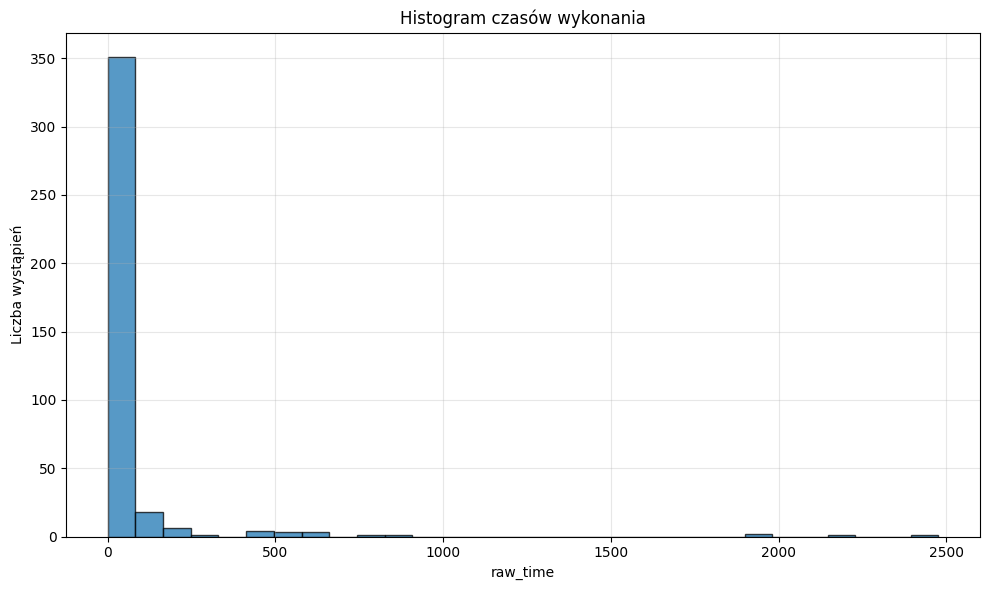

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)

# === 2. Połączenie danych ===
df = results.merge(datasets, on="dataset", how="left")

# === 3. Konwersja typów ===
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")
df = df.dropna(subset=["raw_time", "model"])

# === 4. Wspólny histogram czasów ===
plt.figure(figsize=(10, 6))

plt.hist(
    df["raw_time"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.xlabel("raw_time")
plt.ylabel("Liczba wystąpień")
plt.title("Histogram czasów wykonania")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

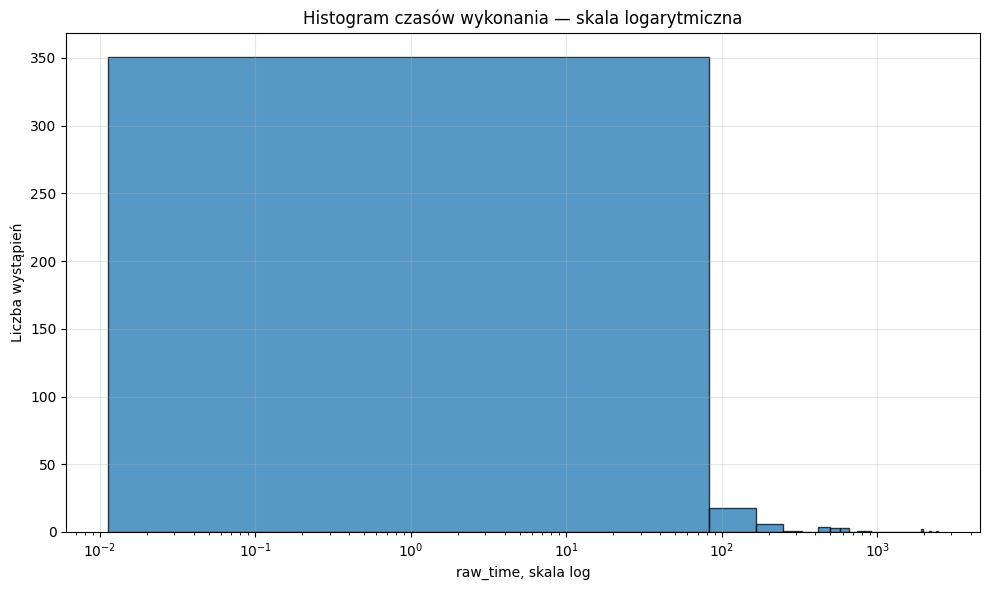

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["raw_time"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.xscale("log")
plt.xlabel("raw_time, skala log")
plt.ylabel("Liczba wystąpień")
plt.title("Histogram czasów wykonania — skala logarytmiczna")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

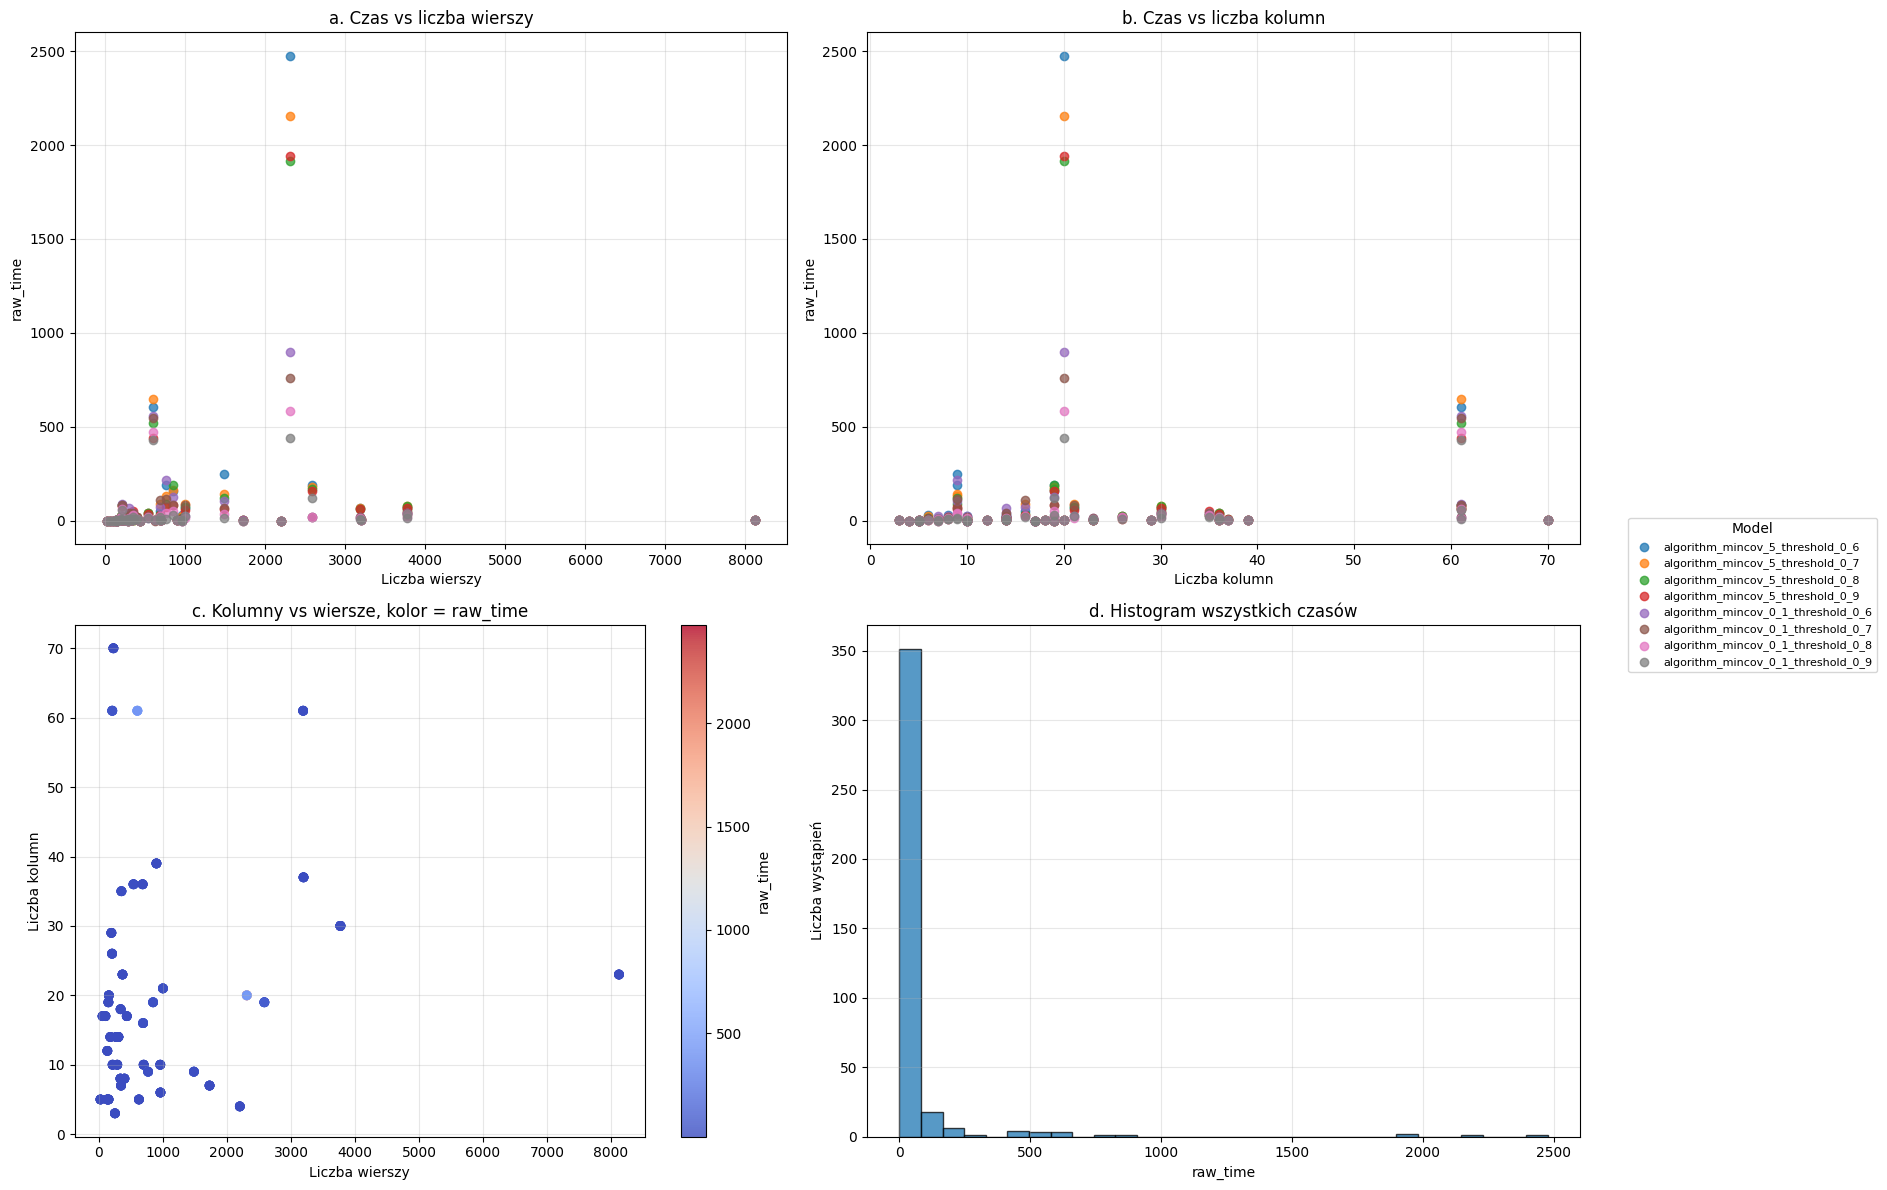

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Wczytanie plików ===
datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)

# === 2. Połączenie danych ===
df = results.merge(datasets, on="dataset", how="left")

# === 3. Konwersja typów ===
df["rows"] = pd.to_numeric(df["rows"], errors="coerce")
df["columns"] = pd.to_numeric(df["columns"], errors="coerce")
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")

df = df.dropna(subset=["rows", "columns", "raw_time", "model"])

# === 4. Jeden wykres 2x2 ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1, ax2, ax3, ax4 = axes.flatten()

# a. czas vs liczba wierszy
for model in df["model"].unique():
    subset = df[df["model"] == model]
    ax1.scatter(
        subset["rows"],
        subset["raw_time"],
        alpha=0.75,
        label=model
    )

ax1.set_xlabel("Liczba wierszy")
ax1.set_ylabel("raw_time")
ax1.set_title("a. Czas vs liczba wierszy")
ax1.grid(True, alpha=0.3)


# b. czas vs liczba kolumn
for model in df["model"].unique():
    subset = df[df["model"] == model]
    ax2.scatter(
        subset["columns"],
        subset["raw_time"],
        alpha=0.75,
        label=model
    )

ax2.set_xlabel("Liczba kolumn")
ax2.set_ylabel("raw_time")
ax2.set_title("b. Czas vs liczba kolumn")
ax2.grid(True, alpha=0.3)


# c. liczba kolumn vs liczba wierszy, czas jako kolor
sc = ax3.scatter(
    df["rows"],
    df["columns"],
    c=df["raw_time"],
    cmap="coolwarm",   # od niebieskiego do czerwonego
    alpha=0.8
)

ax3.set_xlabel("Liczba wierszy")
ax3.set_ylabel("Liczba kolumn")
ax3.set_title("c. Kolumny vs wiersze, kolor = raw_time")
ax3.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=ax3)
cbar.set_label("raw_time")


# d. histogram wszystkich czasów, skala zwykła
ax4.hist(
    df["raw_time"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

ax4.set_xlabel("raw_time")
ax4.set_ylabel("Liczba wystąpień")
ax4.set_title("d. Histogram wszystkich czasów")
ax4.grid(True, alpha=0.3)


# === 5. Wspólna legenda dla modeli ===
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="center right",
    bbox_to_anchor=(1.18, 0.5),
    fontsize=8
)

plt.tight_layout()
plt.show()

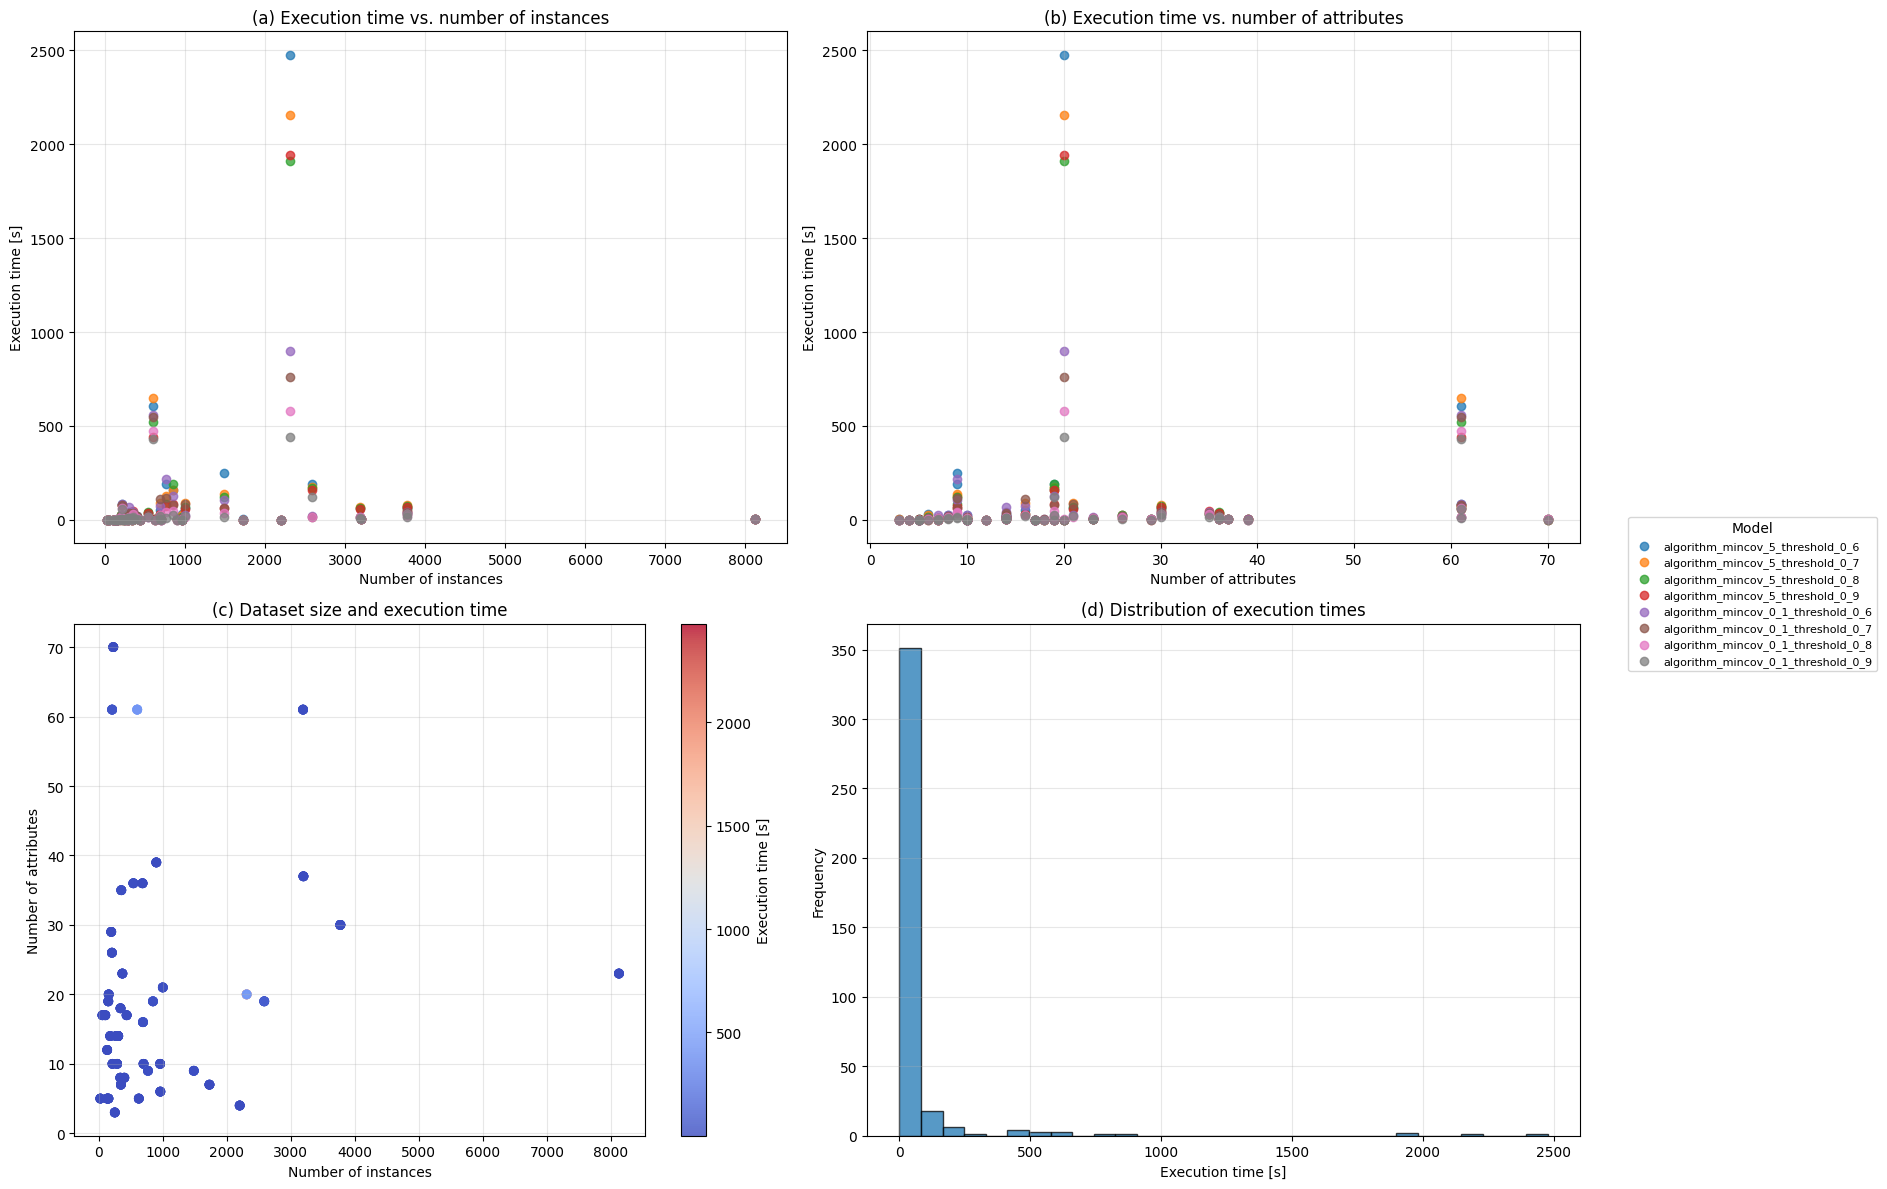

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load input files ===
datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)

# === 2. Merge metadata with results ===
df = results.merge(datasets, on="dataset", how="left")

# === 3. Convert columns to numeric types ===
df["rows"] = pd.to_numeric(df["rows"], errors="coerce")
df["columns"] = pd.to_numeric(df["columns"], errors="coerce")
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")

df = df.dropna(subset=["rows", "columns", "raw_time", "model"])

# === 4. Rename columns for publication-style labels ===
df = df.rename(columns={
    "dataset": "Dataset",
    "model": "Model",
    "rows": "Number of instances",
    "columns": "Number of attributes",
    "raw_time": "Execution time [s]"
})

# === 5. Create 2x2 figure ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1, ax2, ax3, ax4 = axes.flatten()

# a. Execution time vs number of instances
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    ax1.scatter(
        subset["Number of instances"],
        subset["Execution time [s]"],
        alpha=0.75,
        label=model
    )

ax1.set_xlabel("Number of instances")
ax1.set_ylabel("Execution time [s]")
ax1.set_title("(a) Execution time vs. number of instances")
ax1.grid(True, alpha=0.3)


# b. Execution time vs number of attributes
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    ax2.scatter(
        subset["Number of attributes"],
        subset["Execution time [s]"],
        alpha=0.75,
        label=model
    )

ax2.set_xlabel("Number of attributes")
ax2.set_ylabel("Execution time [s]")
ax2.set_title("(b) Execution time vs. number of attributes")
ax2.grid(True, alpha=0.3)


# c. Number of attributes vs number of instances, color = execution time
sc = ax3.scatter(
    df["Number of instances"],
    df["Number of attributes"],
    c=df["Execution time [s]"],
    cmap="coolwarm",
    alpha=0.8
)

ax3.set_xlabel("Number of instances")
ax3.set_ylabel("Number of attributes")
ax3.set_title("(c) Dataset size and execution time")
ax3.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=ax3)
cbar.set_label("Execution time [s]")


# d. Histogram of all execution times
ax4.hist(
    df["Execution time [s]"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

ax4.set_xlabel("Execution time [s]")
ax4.set_ylabel("Frequency")
ax4.set_title("(d) Distribution of execution times")
ax4.grid(True, alpha=0.3)


# === 6. Shared legend ===
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="center right",
    bbox_to_anchor=(1.18, 0.5),
    fontsize=8
)

plt.tight_layout()
plt.show()

First histogram bin range: [0.0112, 82.5517)
Number of observations in first bin: 351


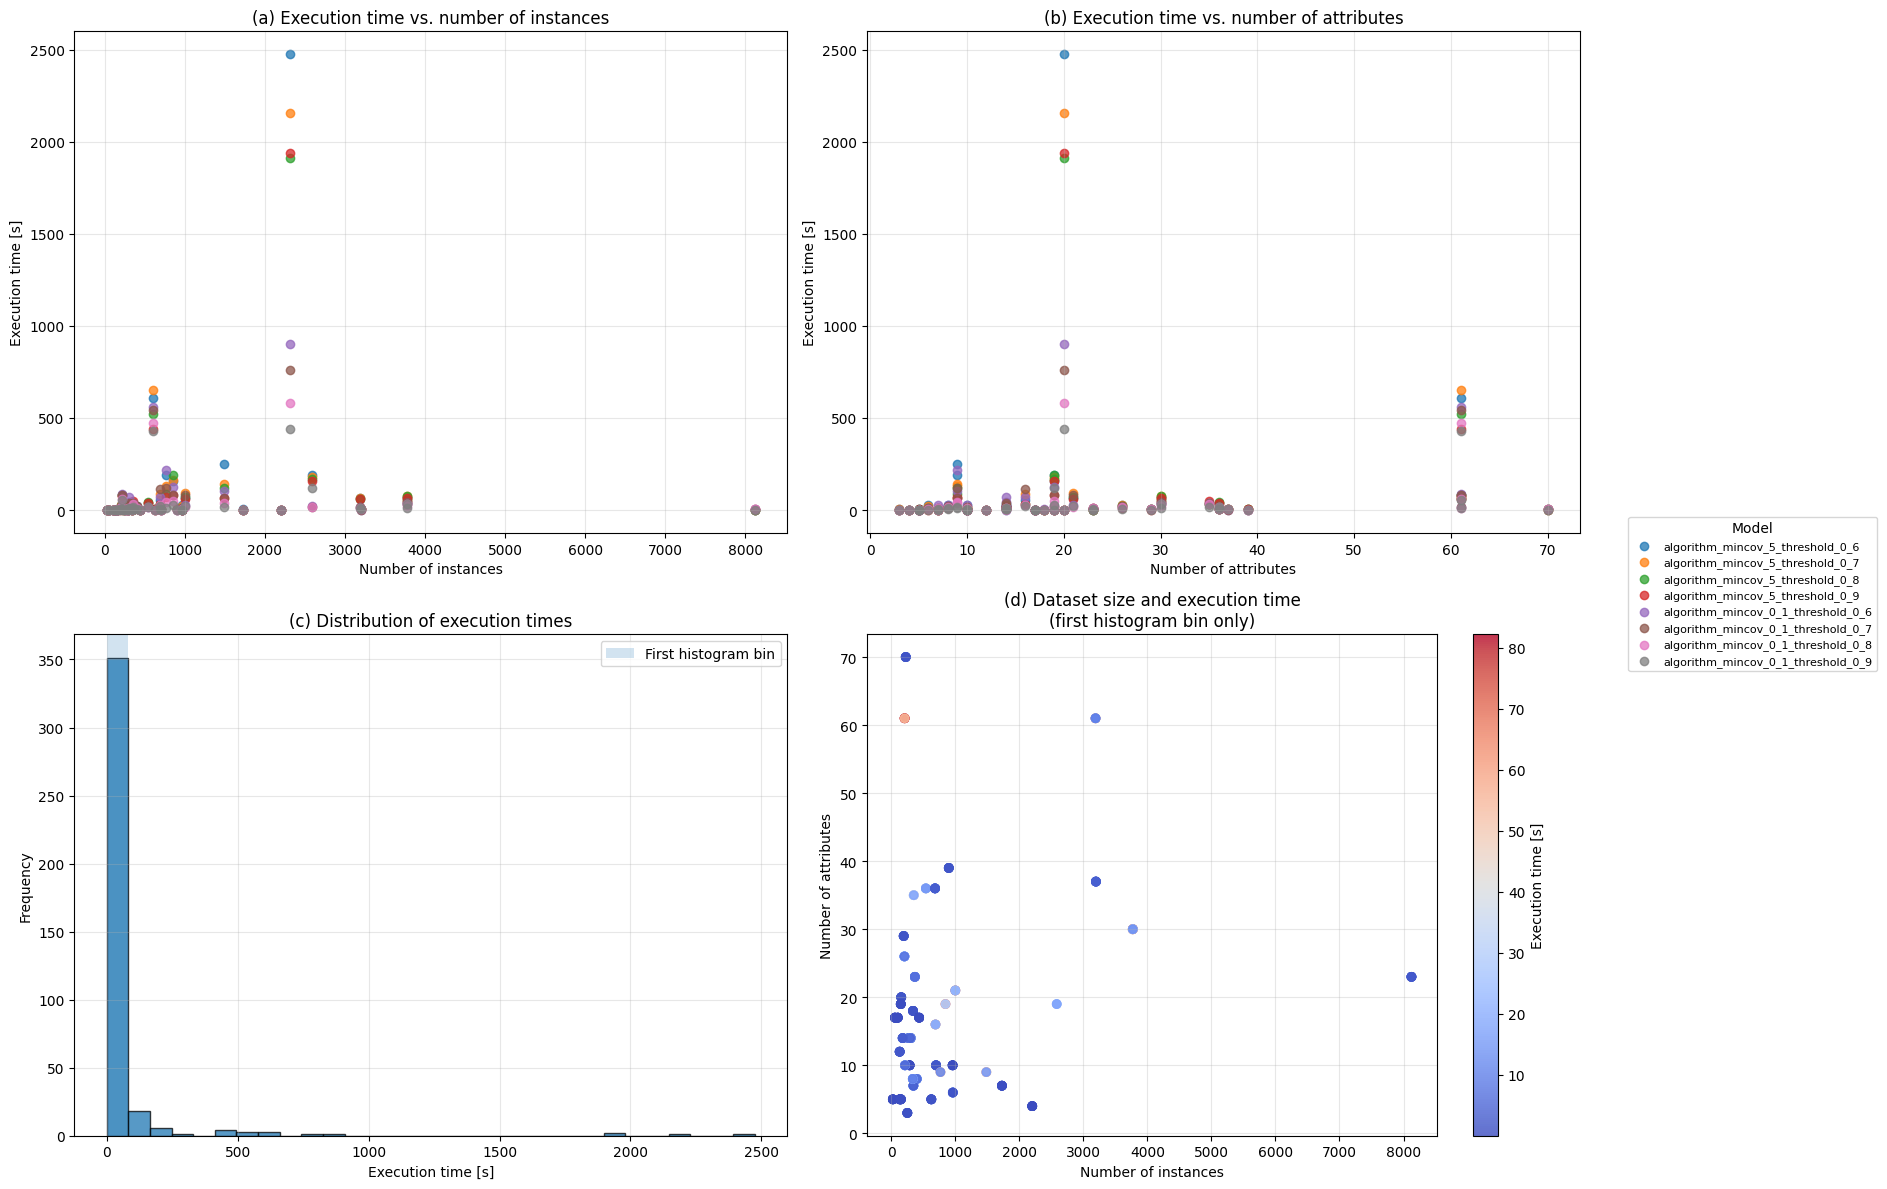

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. Load input files ===
datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)

# === 2. Merge metadata with results ===
df = results.merge(datasets, on="dataset", how="left")

# === 3. Convert columns to numeric types ===
df["rows"] = pd.to_numeric(df["rows"], errors="coerce")
df["columns"] = pd.to_numeric(df["columns"], errors="coerce")
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")

df = df.dropna(subset=["rows", "columns", "raw_time", "model"])

# === 4. Rename columns for publication-style labels ===
df = df.rename(columns={
    "dataset": "Dataset",
    "model": "Model",
    "rows": "Number of instances",
    "columns": "Number of attributes",
    "raw_time": "Execution time [s]"
})

# === 5. Compute histogram bins and select the first bin ===
hist_counts, bin_edges = np.histogram(
    df["Execution time [s]"],
    bins=30
)

first_bin_min = bin_edges[0]
first_bin_max = bin_edges[1]

df_first_bin = df[
    (df["Execution time [s]"] >= first_bin_min) &
    (df["Execution time [s]"] < first_bin_max)
].copy()

print(f"First histogram bin range: [{first_bin_min:.4f}, {first_bin_max:.4f})")
print(f"Number of observations in first bin: {len(df_first_bin)}")

# === 6. Create 2x2 figure ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1, ax2, ax3, ax4 = axes.flatten()

# (a) Execution time vs number of instances
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    ax1.scatter(
        subset["Number of instances"],
        subset["Execution time [s]"],
        alpha=0.75,
        label=model
    )

ax1.set_xlabel("Number of instances")
ax1.set_ylabel("Execution time [s]")
ax1.set_title("(a) Execution time vs. number of instances")
ax1.grid(True, alpha=0.3)


# (b) Execution time vs number of attributes
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    ax2.scatter(
        subset["Number of attributes"],
        subset["Execution time [s]"],
        alpha=0.75,
        label=model
    )

ax2.set_xlabel("Number of attributes")
ax2.set_ylabel("Execution time [s]")
ax2.set_title("(b) Execution time vs. number of attributes")
ax2.grid(True, alpha=0.3)


# (c) Histogram of all execution times
ax3.hist(
    df["Execution time [s]"],
    bins=bin_edges,
    edgecolor="black",
    alpha=0.75
)

ax3.axvspan(
    first_bin_min,
    first_bin_max,
    alpha=0.2,
    label="First histogram bin"
)

ax3.set_xlabel("Execution time [s]")
ax3.set_ylabel("Frequency")
ax3.set_title("(c) Distribution of execution times")
ax3.grid(True, alpha=0.3)
ax3.legend()


# (d) Number of attributes vs number of instances, color = execution time
sc = ax4.scatter(
    df_first_bin["Number of instances"],
    df_first_bin["Number of attributes"],
    c=df_first_bin["Execution time [s]"],
    cmap="coolwarm",
    alpha=0.8
)

ax4.set_xlabel("Number of instances")
ax4.set_ylabel("Number of attributes")
ax4.set_title("(d) Dataset size and execution time\n(first histogram bin only)")
ax4.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=ax4)
cbar.set_label("Execution time [s]")


# === 7. Shared legend for models ===
handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Model",
    loc="center right",
    bbox_to_anchor=(1.18, 0.5),
    fontsize=8
)

plt.tight_layout()
plt.show()

First histogram bin range: [0.0112, 82.5517)
Number of observations in first bin: 351


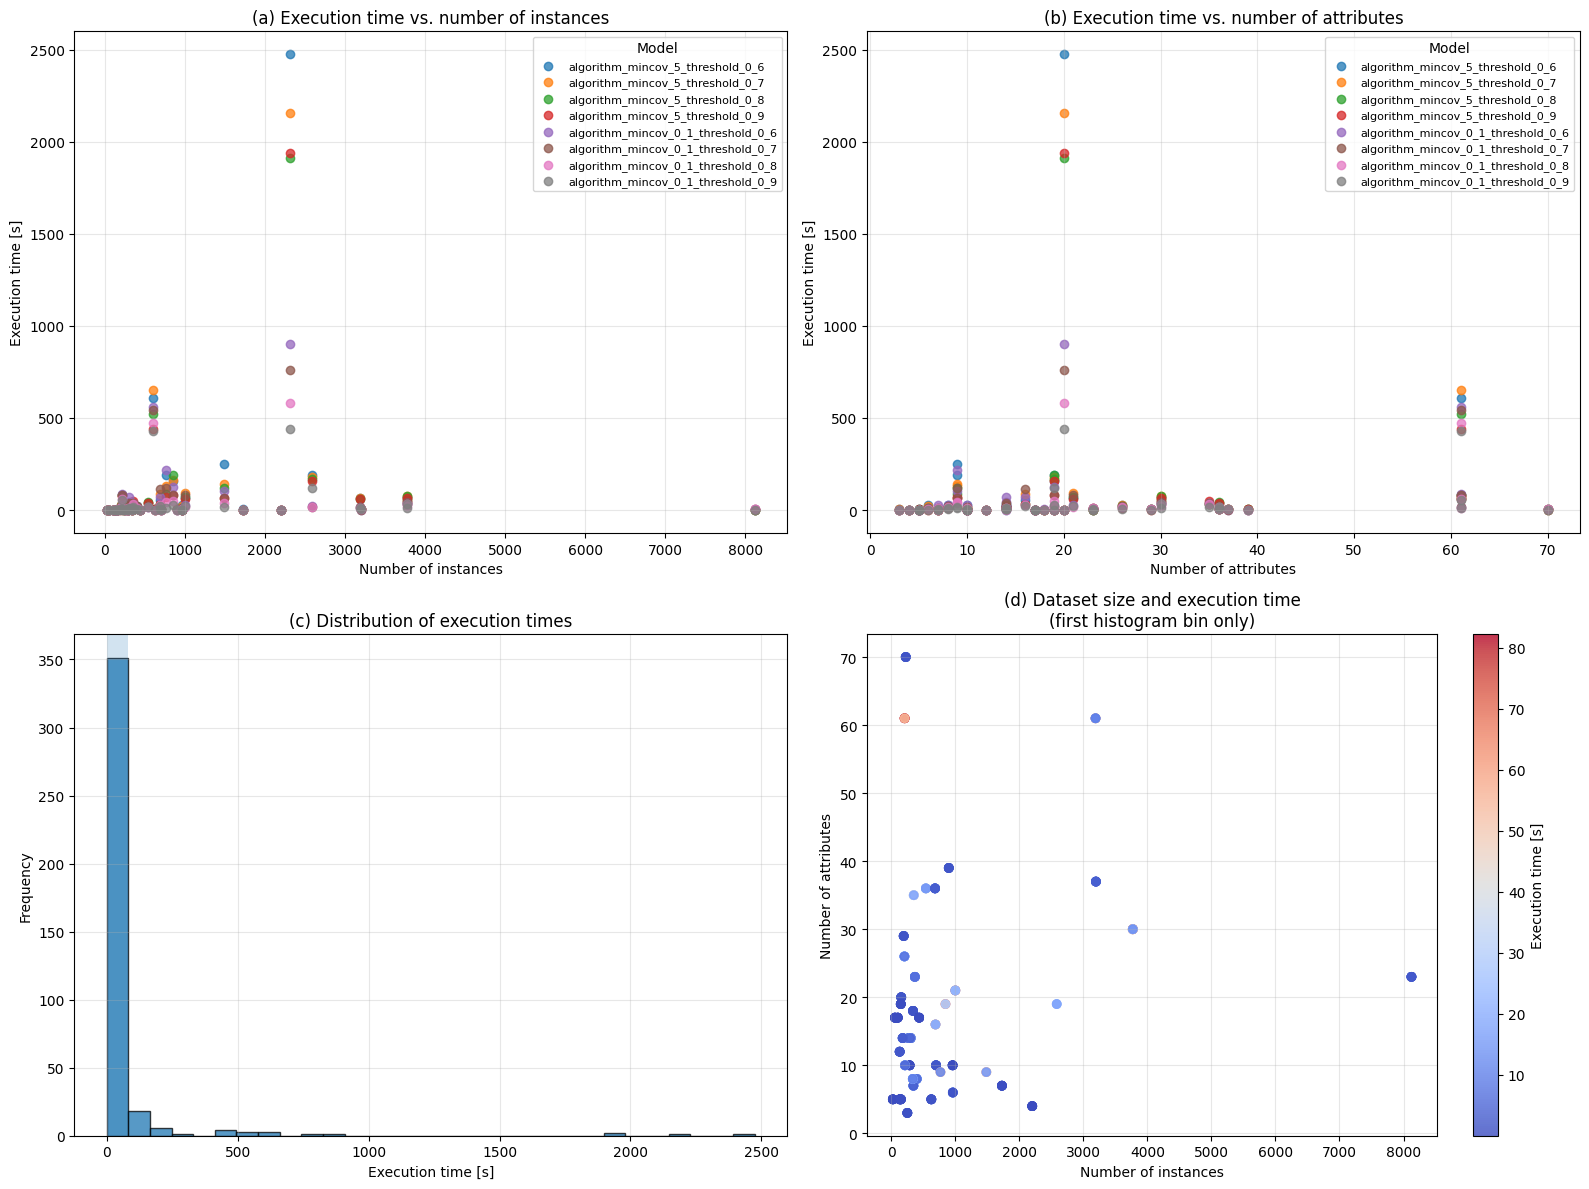

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 1. Load input files ===
datasets_path = "classification_datasets_summary.csv"
path = f"./results_v3/exception_discovery_grid/"
results_path = path+"exceptions_summary_ALL.csv"

datasets = pd.read_csv(datasets_path)
results = pd.read_csv(results_path)

# === 2. Merge metadata with results ===
df = results.merge(datasets, on="dataset", how="left")

# === 3. Convert columns to numeric types ===
df["rows"] = pd.to_numeric(df["rows"], errors="coerce")
df["columns"] = pd.to_numeric(df["columns"], errors="coerce")
df["raw_time"] = pd.to_numeric(df["raw_time"], errors="coerce")

df = df.dropna(subset=["rows", "columns", "raw_time", "model"])

# === 4. Rename columns for publication-style labels ===
df = df.rename(columns={
    "dataset": "Dataset",
    "model": "Model",
    "rows": "Number of instances",
    "columns": "Number of attributes",
    "raw_time": "Execution time [s]"
})

# === 5. Compute histogram bins and select the first bin ===
hist_counts, bin_edges = np.histogram(
    df["Execution time [s]"],
    bins=30
)

first_bin_min = bin_edges[0]
first_bin_max = bin_edges[1]

df_first_bin = df[
    (df["Execution time [s]"] >= first_bin_min) &
    (df["Execution time [s]"] < first_bin_max)
].copy()

print(f"First histogram bin range: [{first_bin_min:.4f}, {first_bin_max:.4f})")
print(f"Number of observations in first bin: {len(df_first_bin)}")

# === 6. Create 2x2 figure ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1, ax2, ax3, ax4 = axes.flatten()

# (a) Execution time vs number of instances
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    ax1.scatter(
        subset["Number of instances"],
        subset["Execution time [s]"],
        alpha=0.75,
        label=model
    )

ax1.set_xlabel("Number of instances")
ax1.set_ylabel("Execution time [s]")
ax1.set_title("(a) Execution time vs. number of instances")
ax1.grid(True, alpha=0.3)
ax1.legend(title="Model", fontsize=8)


# (b) Execution time vs number of attributes
for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    ax2.scatter(
        subset["Number of attributes"],
        subset["Execution time [s]"],
        alpha=0.75,
        label=model
    )

ax2.set_xlabel("Number of attributes")
ax2.set_ylabel("Execution time [s]")
ax2.set_title("(b) Execution time vs. number of attributes")
ax2.grid(True, alpha=0.3)
ax2.legend(title="Model", fontsize=8)


# (c) Histogram of all execution times
ax3.hist(
    df["Execution time [s]"],
    bins=bin_edges,
    edgecolor="black",
    alpha=0.75
)

ax3.axvspan(
    first_bin_min,
    first_bin_max,
    alpha=0.2
)

ax3.set_xlabel("Execution time [s]")
ax3.set_ylabel("Frequency")
ax3.set_title("(c) Distribution of execution times")
ax3.grid(True, alpha=0.3)


# (d) Number of attributes vs number of instances, color = execution time
sc = ax4.scatter(
    df_first_bin["Number of instances"],
    df_first_bin["Number of attributes"],
    c=df_first_bin["Execution time [s]"],
    cmap="coolwarm",
    alpha=0.8
)

ax4.set_xlabel("Number of instances")
ax4.set_ylabel("Number of attributes")
ax4.set_title("(d) Dataset size and execution time\n(first histogram bin only)")
ax4.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=ax4)
cbar.set_label("Execution time [s]")

plt.tight_layout()
plt.show()